In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="latin1")

In [3]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [5]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [6]:
df.columns.to_list()

['num_passengers',
 'sales_channel',
 'trip_type',
 'purchase_lead',
 'length_of_stay',
 'flight_hour',
 'flight_day',
 'route',
 'booking_origin',
 'wants_extra_baggage',
 'wants_preferred_seat',
 'wants_in_flight_meals',
 'flight_duration',
 'booking_complete']

In [8]:
day_mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

In [9]:
df["flight_day_num"] = df["flight_day"].map(day_mapping)

In [19]:
df["is_weekend"] = df["flight_day_num"].apply(lambda x: 1 if x >= 6 else 0)

In [20]:
df_encoded = pd.get_dummies(
    df.drop(columns=["flight_day"]),
    columns=["sales_channel", "trip_type", "route", "booking_origin"],
    drop_first=True,
)

X = df_encoded.drop(columns=["booking_complete"])
y = df_encoded["booking_complete"]

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc_auc = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_accuracy = cross_val_score(
    rf_model, X, y, cv=cv, scoring="accuracy", n_jobs=-1
)

In [23]:
print(
    f"5-Fold CV Mean ROC-AUC Score : {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std():.4f})"
)
print(
    f"5-Fold CV Mean Accuracy Score: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})"
)

5-Fold CV Mean ROC-AUC Score : 0.7709 (+/- 0.0055)
5-Fold CV Mean Accuracy Score: 0.7037 (+/- 0.0037)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       random_state=42)

In [25]:
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)
parent_importances = {}

for feat, imp in importances.items():
  if feat.startswith("route_"):
    parent_importances["route"] = parent_importances.get("route", 0) + imp
  elif feat.startswith("booking_origin_"):
    parent_importances["booking_origin"] = (
        parent_importances.get("booking_origin", 0) + imp
    )
  elif feat.startswith("sales_channel_"):
    parent_importances["sales_channel"] = (
        parent_importances.get("sales_channel", 0) + imp
    )
  elif feat.startswith("trip_type_"):
    parent_importances["trip_type"] = (
        parent_importances.get("trip_type", 0) + imp
    )
  else:
    parent_importances[feat] = imp

parent_series = pd.Series(parent_importances).sort_values(ascending=False)

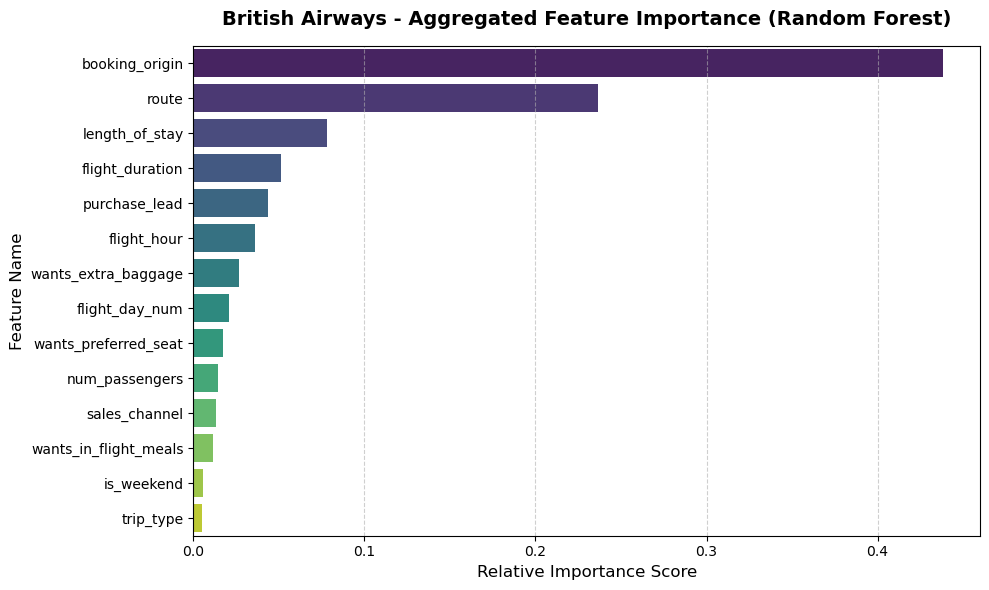

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=parent_series.values, y=parent_series.index, palette="viridis")
plt.title(
    "British Airways - Aggregated Feature Importance (Random Forest)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("ba_feature_importance.png", dpi=300)
plt.show()